# Heart Disease Prediction

## Problem Statement
The goal of this project is to predict whether a patient is likely to have heart disease based on medical attributes using Machine Learning classification models.

Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [5]:
df = pd.read_csv('../data/archive/heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Dataset Overview

In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1025, 14)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Missing Values

In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Observation
The dataset does not contain any missing values, it is ready for analysis and model training.

## Exploratory Data Analysis
### Target Variable Distribution

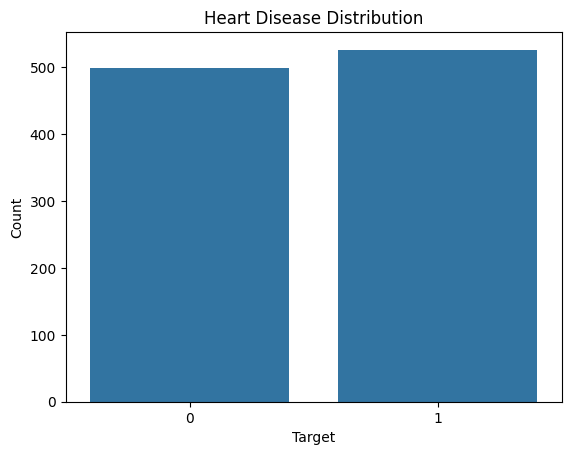

In [16]:
sns.countplot(x='target', data=df)

plt.title('Heart Disease Distribution')
plt.xlabel('Target')
plt.ylabel('Count')

plt.show()

### Observation
The target variable distribution shows that the dataset is relatively balanced, with a similar number of patients having heart disease and not having heart disease.

### Correlation Heatmap

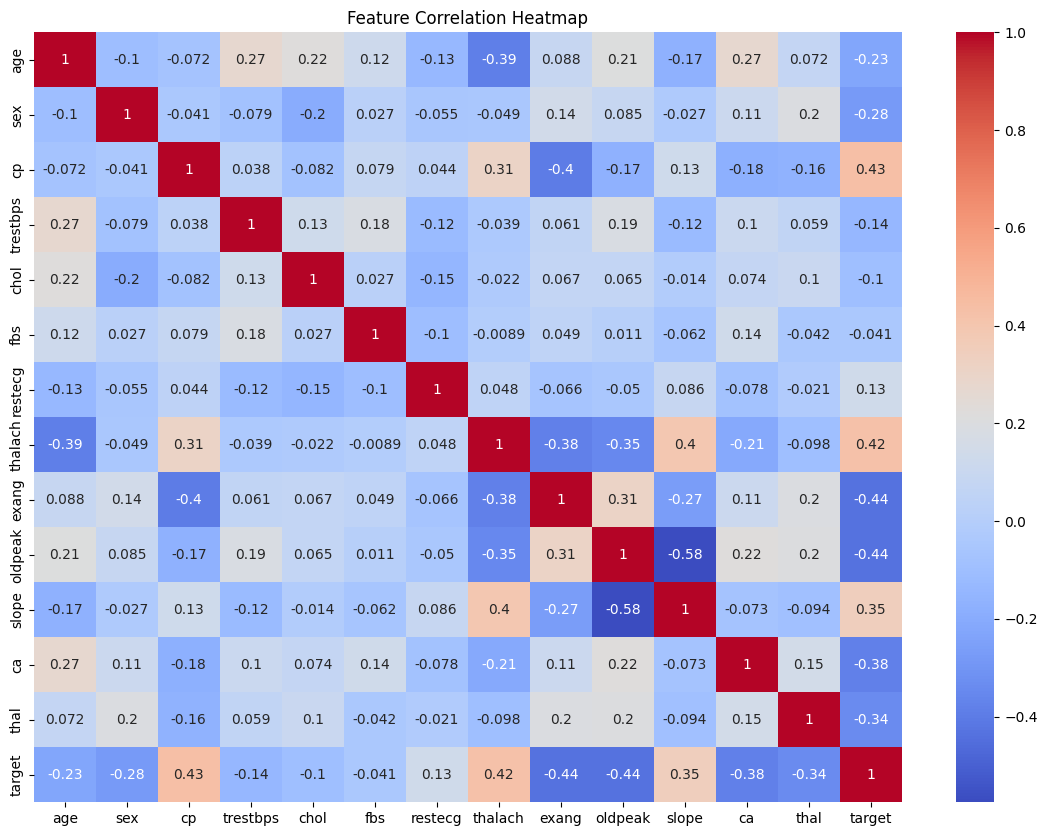

In [17]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Feature Correlation Heatmap')

plt.show()

### Observation

Several medical features show noticeable correlation with the target variable, particularly chest pain type, maximum heart rate, and exercise-induced angina. These features may play an important role in predicting heart disease.

### Age Distribution

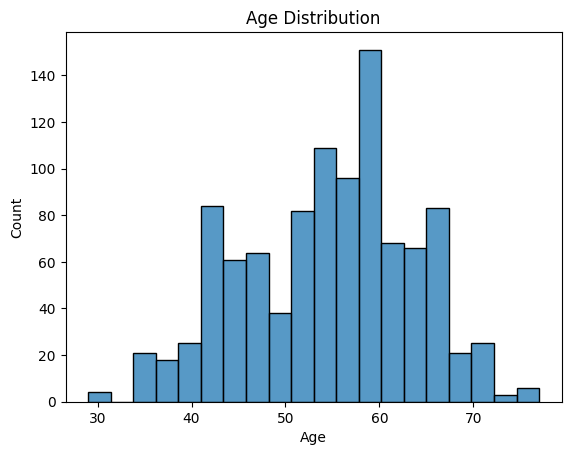

In [18]:
sns.histplot(df['age'], bins=20)

plt.title('Age Distribution')

plt.xlabel('Age')

plt.show()

### Observation

Most patients fall within the middle-aged to older age groups. Heart disease cases appear more common among older individuals, suggesting age may be an important risk factor.

### Chest Pain Type vs Heart Disease

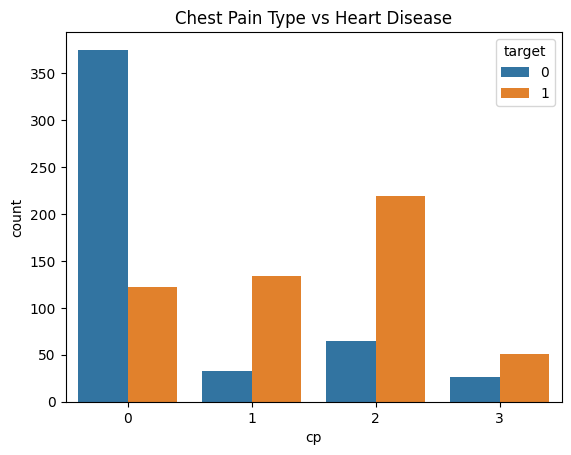

In [19]:
sns.countplot(x='cp', hue='target', data=df)

plt.title('Chest Pain Type vs Heart Disease')

plt.show()

### Observation

Certain chest pain categories are more strongly associated with heart disease cases. This indicates that chest pain type is a significant medical indicator for diagnosis.

### Gender vs Heart Disease

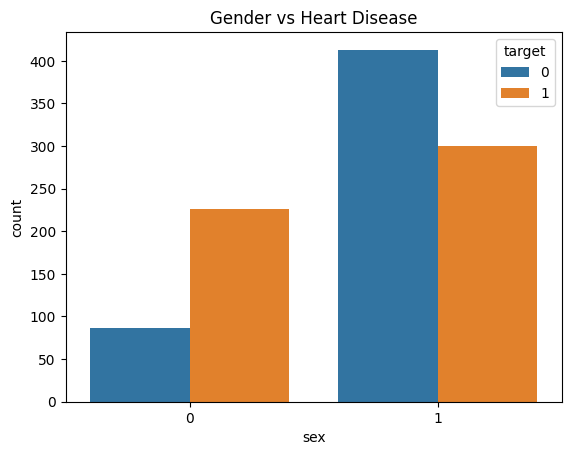

In [20]:
sns.countplot(x='sex', hue='target', data=df)

plt.title('Gender vs Heart Disease')

plt.show()

### Observation
Heart disease appears to be more common among male patients compared to female patients.

### Maximum Heart Rate Distribution

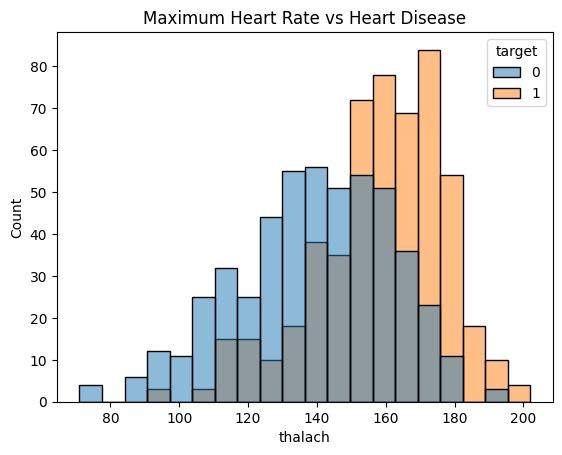

In [21]:
sns.histplot(data=df, x='thalach', hue='target', bins=20)

plt.title('Maximum Heart Rate vs Heart Disease')

plt.show()

### Observation

Patients with heart disease show noticeable variation in maximum heart rate values. Maximum heart rate may contribute significantly to distinguishing between positive and negative cases.

### Exercise Induced Angina Analysis

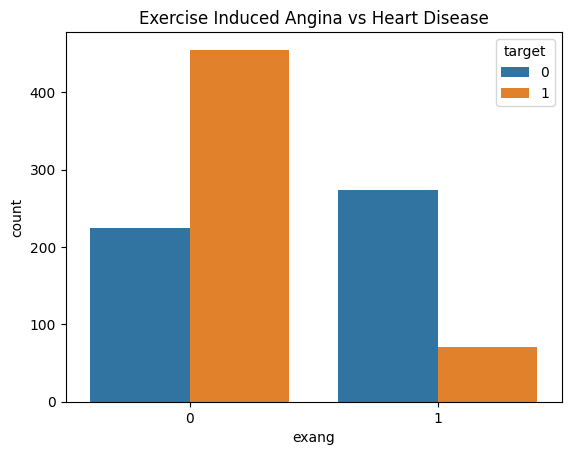

In [22]:
sns.countplot(x='exang', hue='target', data=df)

plt.title('Exercise Induced Angina vs Heart Disease')

plt.show()

### Observation

Patients experiencing exercise-induced angina are more likely to have heart disease. This feature demonstrates strong relevance in cardiovascular health assessment.

### Cholesterol Distribution

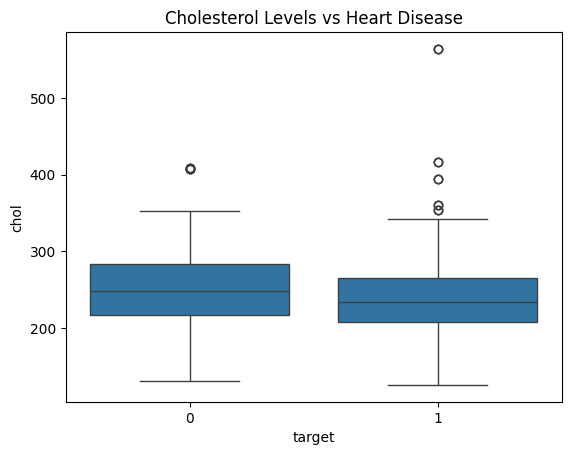

In [23]:
sns.boxplot(x='target', y='chol', data=df)

plt.title('Cholesterol Levels vs Heart Disease')

plt.show()

### Observation

Cholesterol levels vary across patients with and without heart disease. Although some overlap exists, elevated cholesterol may still contribute to cardiovascular risk.

### Resting Blood Pressure Distribution

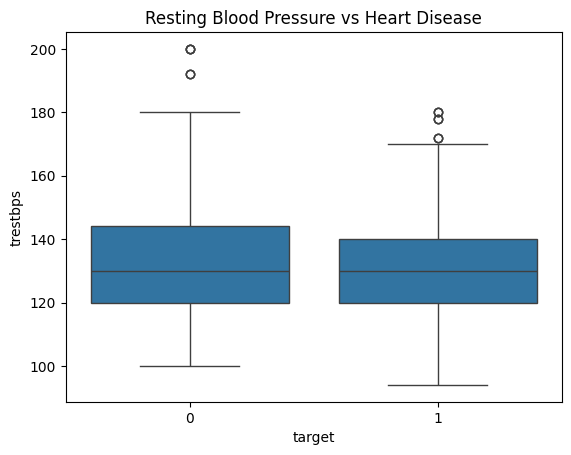

In [24]:
sns.boxplot(x='target', y='trestbps', data=df)

plt.title('Resting Blood Pressure vs Heart Disease')

plt.show()

### Observation

Resting blood pressure values show variation among heart disease patients. Higher blood pressure levels may be associated with increased cardiovascular risk.

# Feature Selection and Model Training

## Feature Selection

In [25]:
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1025, 13)
Target shape: (1025,)


### Observation

The dataset contains 1025 patient records with 13 medical features used for prediction.

The target variable represents the presence or absence of heart disease, making this a binary classification problem.

## Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (820, 13)
Testing data shape: (205, 13)


### Observation

The dataset was divided into training and testing sets using an 80-20 split.

A total of 820 samples were used for training the Logistic Regression model, while 205 samples were reserved for testing and evaluating model performance on unseen data.

## Feature Scaling

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression Model Training

In [28]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Model Predictions

In [29]:
y_pred = model.predict(X_test)

## Model Accuracy

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7951219512195122


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



## Model Performance Observation

The Logistic Regression model achieved an accuracy of approximately 79.5%, indicating strong predictive capability on the heart disease dataset.

The model demonstrated particularly strong recall for patients with heart disease (87%), which is important in healthcare applications because identifying positive disease cases is critical.

Overall, the model shows balanced performance across precision, recall, and F1-score metrics.

## Confusion Matrix

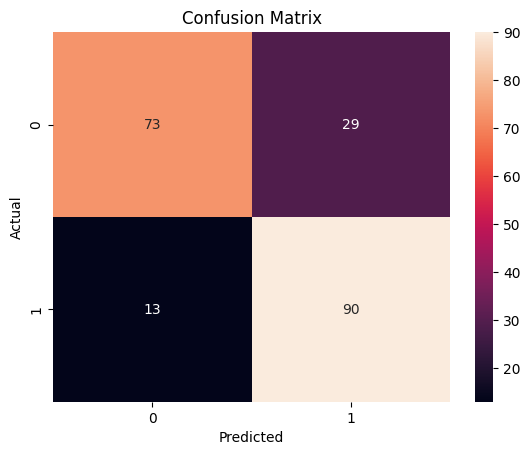

In [32]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Observation

The confusion matrix shows that the model performed well in predicting heart disease cases. It correctly classified most patients, with 73 true negatives and 90 true positives. The model made relatively few errors, especially only 13 false negatives.

## ROC Curve

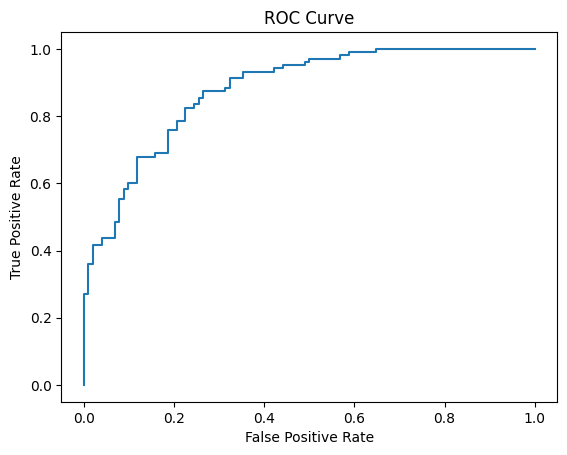

ROC AUC Score: 0.8787359604035789


In [33]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

### Observation

The model achieved an ROC AUC score of 0.88, indicating strong ability to distinguish between heart disease and non-heart disease cases.

This suggests that the Logistic Regression model performs well as a binary classifier for this healthcare dataset.

## Feature Importance

In [34]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
2,cp,0.885835
7,thalach,0.652826
10,slope,0.343605
6,restecg,0.140804
0,age,-0.006734
5,fbs,-0.062685
3,trestbps,-0.320053
8,exang,-0.420235
4,chol,-0.447276
12,thal,-0.656856


### Observation

The Logistic Regression coefficients reveal that chest pain type (`cp`) has the highest positive impact on predicting heart disease, followed by maximum heart rate (`thalach`) and slope.

Features such as `ca`, `sex`, and `oldpeak` have strong negative coefficients, showing substantial influence in distinguishing between positive and negative cases.

Overall, the model identifies cardiovascular diagnostic indicators as the most important predictive features.

# Conclusion

This project explored the use of Machine Learning for predicting heart disease using patient medical data.

Exploratory Data Analysis (EDA) revealed several important relationships between medical features and heart disease occurrence, including chest pain type, maximum heart rate, exercise-induced angina, and cholesterol levels.

A Logistic Regression model was trained and evaluated on the dataset. The model achieved an accuracy of approximately 79.5%, demonstrating strong predictive performance for this healthcare classification task.

The model also achieved high recall for heart disease cases, which is especially important in medical applications where identifying positive cases is critical.

Overall, this project demonstrates how Machine Learning techniques can assist in early heart disease prediction and healthcare analytics.